In [331]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import canny
from skimage.transform import hough_line, hough_line_peaks
from skimage.draw import line as draw_line

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.cmap"] = "gray"


Q1


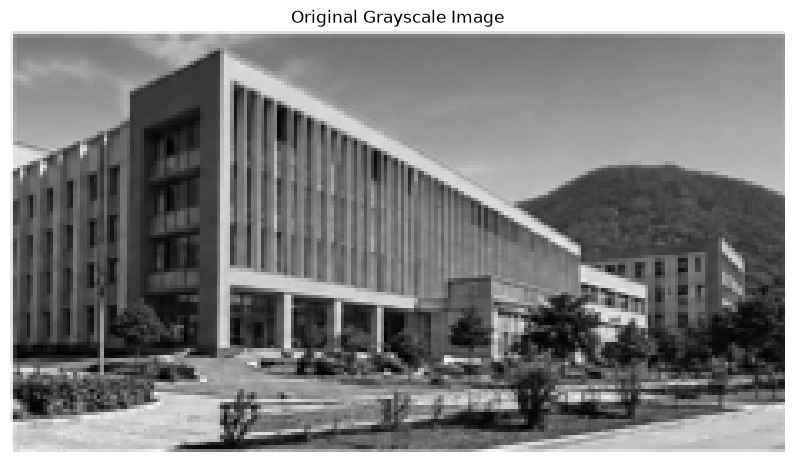

In [332]:

line_image_path = "line_image.jpg"

img = cv2.imread(line_image_path)
if img is None:
    raise FileNotFoundError(f"Could not read {line_image_path}")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  #convert to grayscale

plt.imshow(gray)
plt.title("Original Grayscale Image")
plt.axis("off");


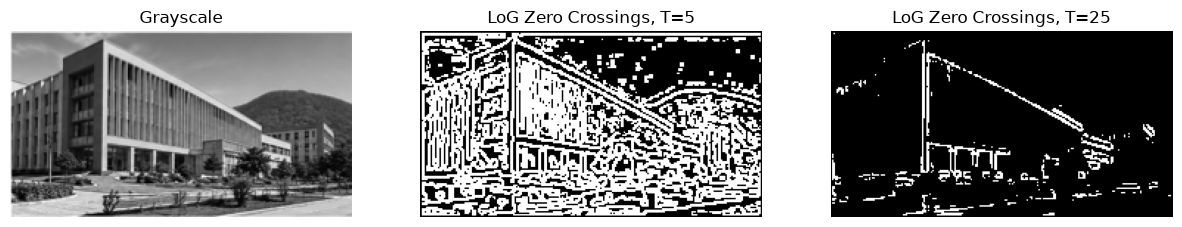

In [333]:
def log_response(gray_image, sigma=1.5):
    # Gaussian smoothing
    blurred = cv2.GaussianBlur(gray_image, (0, 0), sigma)  # image , (kernel size) , sigma  ; (0,0) means decide acc to round(6*sigma +1)

    # Laplacian of Gaussian response
    log = cv2.Laplacian(blurred, cv2.CV_64F) #64bit float to prevent overflow &underflow
    return log


def zero_crossing(log, threshold=0):
    # Detect sign changes in a 3x3 neighborhood.
    h, w = log.shape
    result = np.zeros((h, w), dtype=np.uint8)

    for y in range(1, h - 1):
        for x in range(1, w - 1):
            patch = log[y-1:y+2, x-1:x+2] # to select subgrid centered at (y,x) [row range , col range]

            p_min = patch.min()
            p_max = patch.max()

            # A zero crossing exists if the neighborhood contains
            # both positive and negative values.
            if p_min < 0 and p_max > 0:
                # Threshold controls suppression of weak responses.
                if (p_max - p_min) >= threshold:
                    result[y, x] = 255

    return result


log = log_response(gray, sigma=1.5)

# Two threshold settings
low_threshold = 5
high_threshold = 25

edges_low = zero_crossing(log, threshold=low_threshold)
edges_high = zero_crossing(log, threshold=high_threshold)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(gray, cmap="gray")
ax[0].set_title("Grayscale")
ax[1].imshow(edges_low, cmap="gray")
ax[1].set_title(f"LoG Zero Crossings, T={low_threshold}")
ax[2].imshow(edges_high, cmap="gray")
ax[2].set_title(f"LoG Zero Crossings, T={high_threshold}")

for a in ax:
    a.axis("off")
plt.show()


Number of detected lines with low LoG threshold: 140
Number of detected lines with high LoG threshold: 8


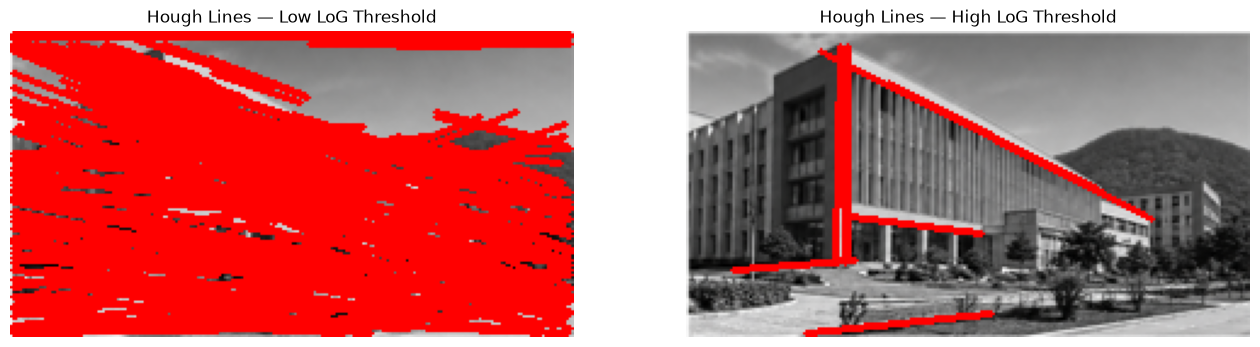

In [334]:
def hough_lines_and_overlay(original_bgr, edge_image,
                            threshold=80, min_line_length=30, max_line_gap=10):

    lines = cv2.HoughLinesP(
        edge_image,
        rho=1,
        theta=np.pi / 180,
        threshold=threshold,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap
    )

    overlay = original_bgr.copy()

    if lines is not None:
        # Make the output consistently shaped as (N, 4)
        lines = np.asarray(lines).reshape(-1, 4)

        for x1, y1, x2, y2 in lines:
            cv2.line(
                overlay,
                (int(x1), int(y1)),
                (int(x2), int(y2)),
                (0, 0, 255),
                2
            )

    return overlay, lines

overlay_low, lines_low = hough_lines_and_overlay(
    img,
    edges_low,
    threshold=50,
    min_line_length=30,
    max_line_gap=10
)

overlay_high, lines_high = hough_lines_and_overlay(
    img,
    edges_high,
    threshold=50,
    min_line_length=30,
    max_line_gap=10
)

print("Number of detected lines with low LoG threshold:",
      0 if lines_low is None else len(lines_low))

print("Number of detected lines with high LoG threshold:",
      0 if lines_high is None else len(lines_high))

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

ax[0].imshow(cv2.cvtColor(overlay_low, cv2.COLOR_BGR2RGB))
ax[0].set_title("Hough Lines — Low LoG Threshold")
ax[1].imshow(cv2.cvtColor(overlay_high, cv2.COLOR_BGR2RGB))
ax[1].set_title("Hough Lines — High LoG Threshold")

for a in ax:
    a.axis("off")
plt.show()


### Q1 Discussion

A lower LoG threshold retains weaker zero-crossing responses. This generally produces a denser edge map, which can increase the number of Hough-detected lines but may also introduce false detections caused by noise and insignificant intensity changes.

A higher LoG threshold suppresses weak responses. The resulting edge map is usually cleaner, but genuinely weak or partially visible lines may disappear, leading to missed detections.

Therefore, the threshold should be selected as a compromise between retaining real structures and suppressing noise.

Q2

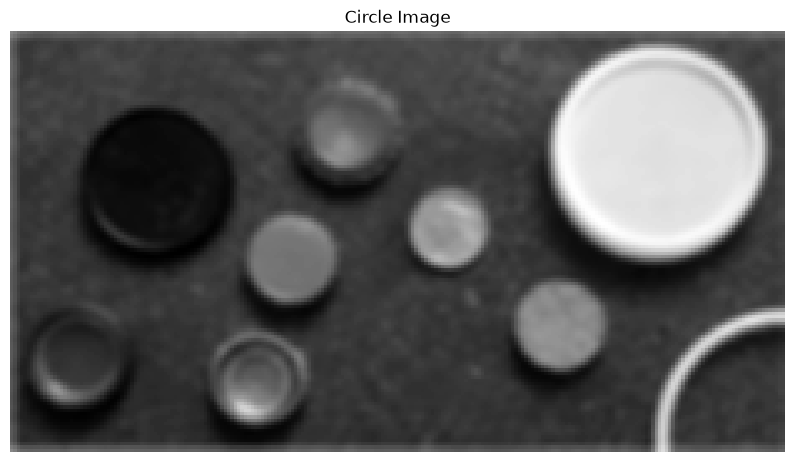

In [335]:

circle_image_path = "circle_image.jpg"

circle_img = cv2.imread(circle_image_path)
if circle_img is None:
    raise FileNotFoundError(f"Could not read {circle_image_path}")

circle_gray = cv2.cvtColor(circle_img, cv2.COLOR_BGR2GRAY)
circle_gray = cv2.GaussianBlur(circle_gray, (5, 5), 1.2)

plt.imshow(circle_gray, cmap="gray")
plt.title("Circle Image")
plt.axis("off");


Detections with param2=30: 10
Detections with param2=45: 7


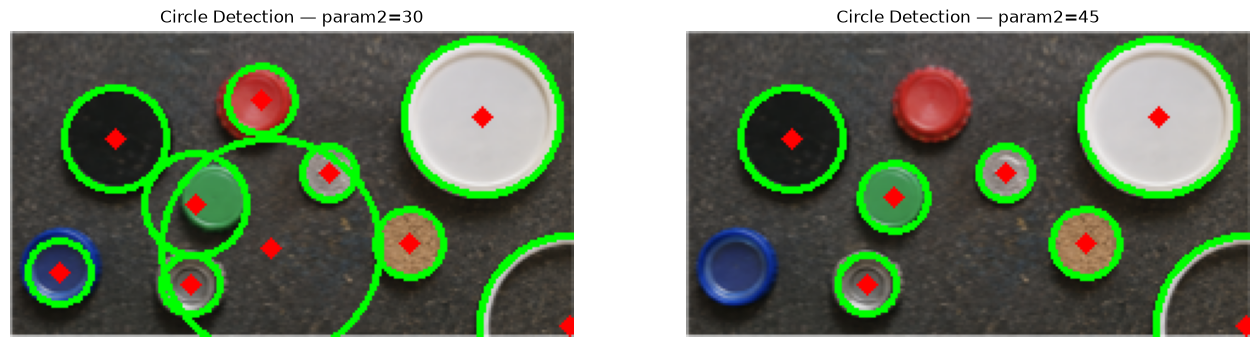

In [ ]:
def detect_circles(image_bgr, gray_image,
                    min_radius=10, max_radius=100, param2=30):
    circles = cv2.HoughCircles(
        gray_image,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=20,
        param1=100,
        param2=param2,
        minRadius=min_radius,
        maxRadius=max_radius
    )

    output = image_bgr.copy()

    if circles is not None:
        circles = np.round(circles[0]).astype(int)

        for x, y, r in circles:
            cv2.circle(output, (x, y), r, (0, 255, 0), 2)
            cv2.circle(output, (x, y), 2, (0, 0, 255), 3)

    return output, circles


# First parameter setting
circle_result_1, circles_1 = detect_circles(
    circle_img, circle_gray,
    min_radius=10,
    max_radius=100,
    param2=30
)

# Second setting: more restrictive detection threshold
circle_result_2, circles_2 = detect_circles(
    circle_img, circle_gray,
    min_radius=10,
    max_radius=100,
    param2=45
)

print("Detections with param2=30:",
      0 if circles_1 is None else len(circles_1))
print("Detections with param2=45:",
      0 if circles_2 is None else len(circles_2))

fig, ax = plt.subplots(1, 2, figsize=(16, 7))
ax[0].imshow(cv2.cvtColor(circle_result_1, cv2.COLOR_BGR2RGB))
ax[0].set_title("Circle Detection — param2=30")
ax[1].imshow(cv2.cvtColor(circle_result_2, cv2.COLOR_BGR2RGB))
ax[1].set_title("Circle Detection — param2=45")

for a in ax:
    a.axis("off")
plt.show()


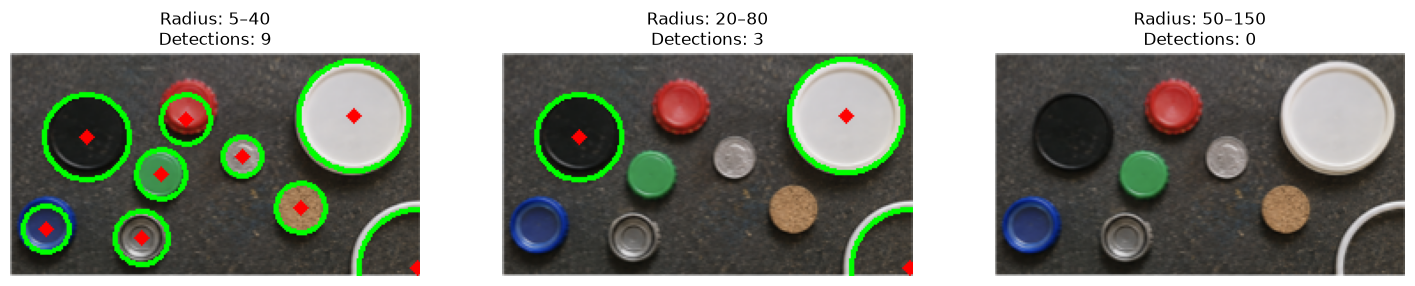

In [337]:

radius_settings = [
    (5, 40),
    (20, 80),
    (50, 150)
]

fig, axes = plt.subplots(1, len(radius_settings), figsize=(18, 6))

for ax, (rmin, rmax) in zip(axes, radius_settings):
    result, circles = detect_circles(
        circle_img, circle_gray,
        min_radius=rmin,
        max_radius=rmax,
        param2=30
    )

    count = 0 if circles is None else len(circles)
    ax.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Radius: {rmin}–{rmax}\nDetections: {count}")
    ax.axis("off")

plt.show()


### Q2 Discussion

The radius range should cover the actual sizes of the circular objects while excluding unrealistic sizes. If the range is too broad, false detections can increase because many possible circles are considered.

Increasing `param2` makes the detector more conservative: weak circle candidates are rejected, reducing false positives but potentially causing missed circles. Decreasing it makes the detector more sensitive and can recover partially visible circles, but may also produce false detections.

**Best parameters:** record the values that give the most accurate result for the selected image after visual inspection.

In our observations `param2` = 40(to detect comparably bigger caps with better boundary) or 31(to detect smaller caps also) is good.

Q3


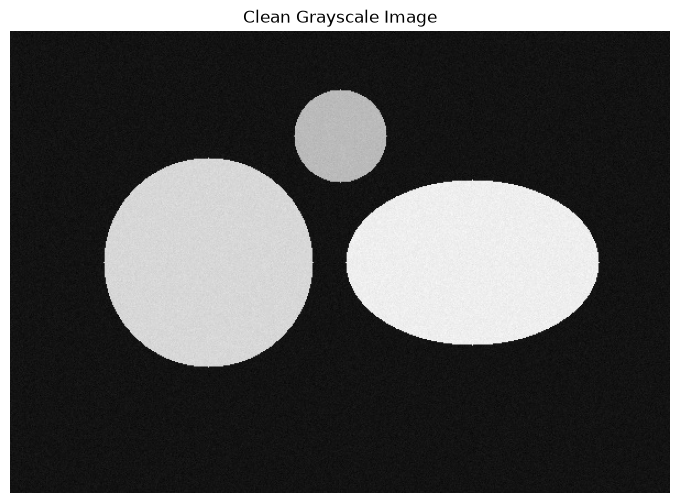

In [338]:


noise_image_path = "clean_image.jpg"

clean = cv2.imread(noise_image_path, cv2.IMREAD_GRAYSCALE)
if clean is None:
    raise FileNotFoundError(f"Could not read {noise_image_path}")

plt.imshow(clean, cmap="gray")
plt.title("Clean Grayscale Image")
plt.axis("off");


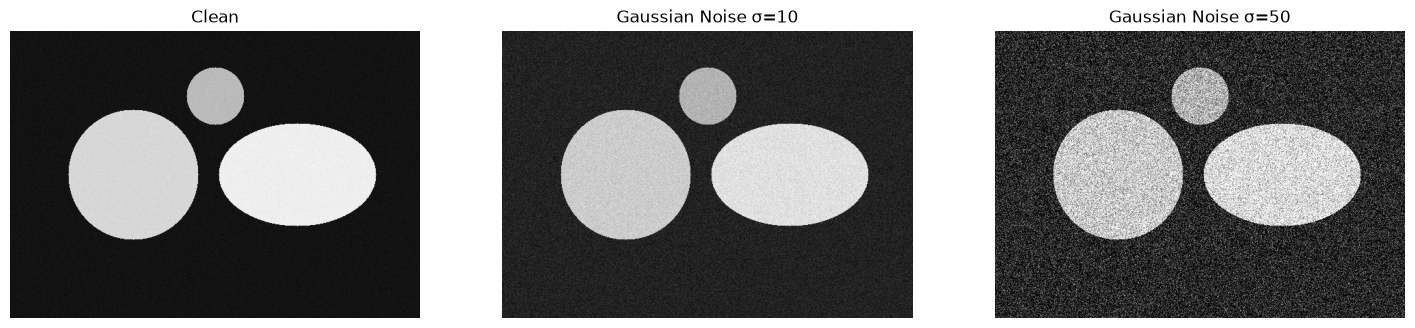

In [339]:
def add_gaussian_noise(image, sigma, mean=0):
    noise = np.random.normal(mean, sigma, image.shape)
    noisy = image.astype(np.float64) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)


np.random.seed(42)

noisy_10 = add_gaussian_noise(clean, sigma=10)
noisy_50 = add_gaussian_noise(clean, sigma=50)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].imshow(clean, cmap="gray")
ax[0].set_title("Clean")
ax[1].imshow(noisy_10, cmap="gray")
ax[1].set_title("Gaussian Noise σ=10")
ax[2].imshow(noisy_50, cmap="gray")
ax[2].set_title("Gaussian Noise σ=50")

for a in ax:
    a.axis("off")
plt.show()


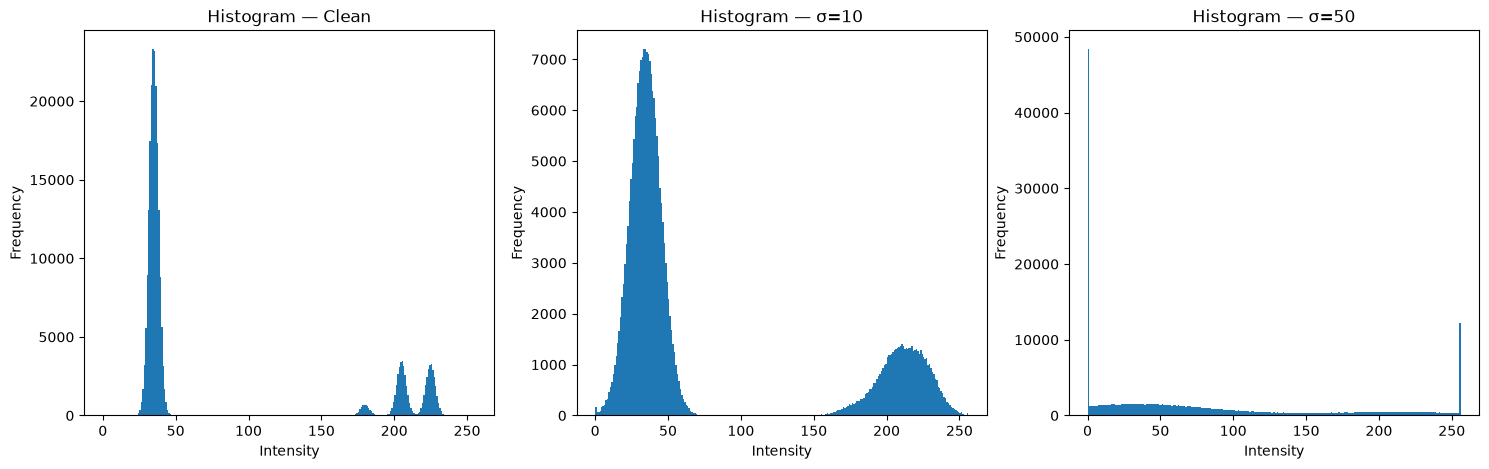

In [340]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].hist(clean.ravel(), bins=256, range=(0, 256))
ax[0].set_title("Histogram — Clean")

ax[1].hist(noisy_10.ravel(), bins=256, range=(0, 256))
ax[1].set_title("Histogram — σ=10")

ax[2].hist(noisy_50.ravel(), bins=256, range=(0, 256))
ax[2].set_title("Histogram — σ=50")

for a in ax:
    a.set_xlabel("Intensity")
    a.set_ylabel("Frequency")

plt.show()


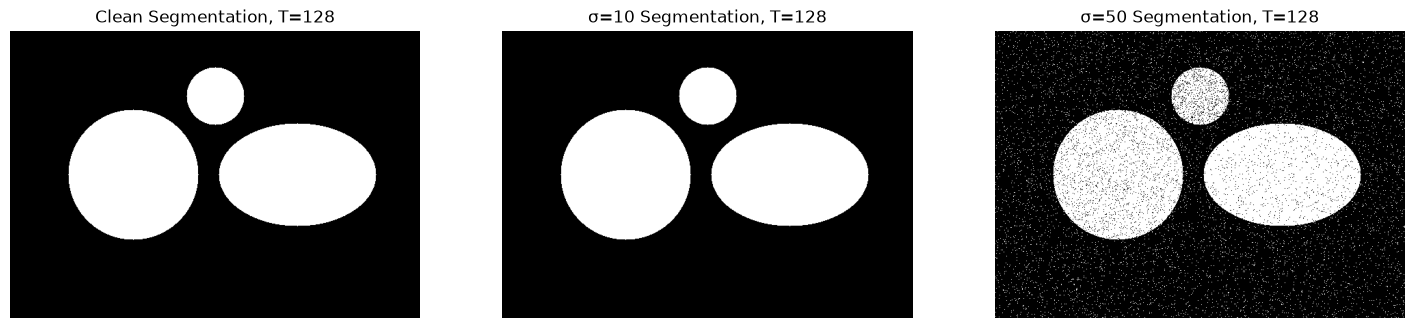

In [341]:

global_threshold = 128

seg_clean = (clean >= global_threshold).astype(np.uint8) * 255
seg_10 = (noisy_10 >= global_threshold).astype(np.uint8) * 255
seg_50 = (noisy_50 >= global_threshold).astype(np.uint8) * 255

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(seg_clean, cmap="gray")
ax[0].set_title(f"Clean Segmentation, T={global_threshold}")

ax[1].imshow(seg_10, cmap="gray")
ax[1].set_title(f"σ=10 Segmentation, T={global_threshold}")

ax[2].imshow(seg_50, cmap="gray")
ax[2].set_title(f"σ=50 Segmentation, T={global_threshold}")

for a in ax:
    a.axis("off")

plt.show()


### Q3 Discussion

Gaussian noise spreads pixel intensities around their original values. For σ = 10, the histogram generally becomes broader but the foreground and background may still remain reasonably separated.

For σ = 50, the spreading is much stronger. Histogram peaks can overlap substantially, making a single global threshold less reliable. Pixels close to the chosen threshold can switch between foreground and background, producing noisy or incorrect segmentation.

Thus, increasing noise makes threshold selection harder and generally reduces the quality of global thresholding.

# Q4. Global Thresholding using Otsu's Method

The assignment requires implementing Otsu's method **from scratch**.

For every threshold T:
- Compute class probabilities.
- Compute class means.
- Compute between-class variance.
- Select the T that maximizes between-class variance.

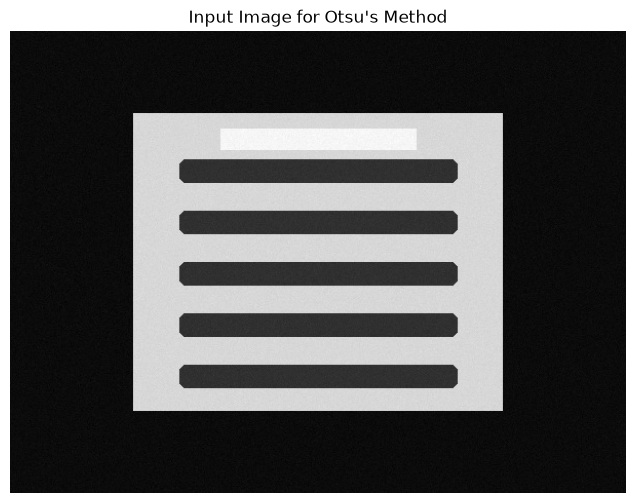

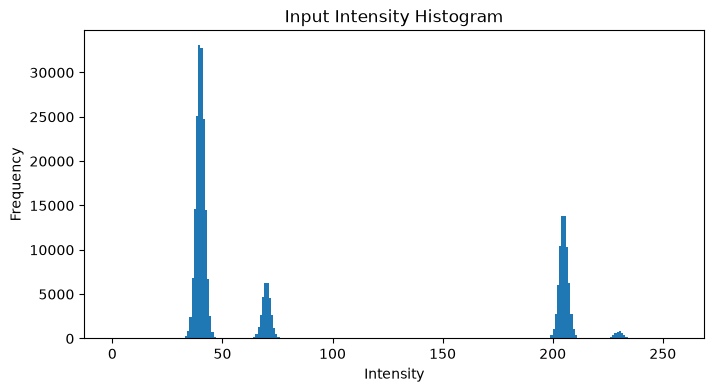

In [342]:

otsu_image_path = "otsu_image.jpg"

otsu_img = cv2.imread(otsu_image_path, cv2.IMREAD_GRAYSCALE)
if otsu_img is None:
    raise FileNotFoundError(f"Could not read {otsu_image_path}")

plt.imshow(otsu_img, cmap="gray")
plt.title("Input Image for Otsu's Method")
plt.axis("off");

plt.figure(figsize=(8, 4))
plt.hist(otsu_img.ravel(), bins=256, range=(0, 256))
plt.title("Input Intensity Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()


In [343]:
def otsu_from_scratch(image):
    # Histogram of intensity values 0...255
    hist, _ = np.histogram(image.ravel(), bins=256, range=(0, 256))

    # Normalized histogram = probability of each intensity
    probabilities = hist.astype(np.float64) / image.size

    intensities = np.arange(256)

    # Global mean intensity
    global_mean = np.sum(intensities * probabilities)

    between_class_variance = np.zeros(256)

    for T in range(256):
        # Class 0: intensities <= T
        # Class 1: intensities > T
        w0 = np.sum(probabilities[:T + 1])
        w1 = np.sum(probabilities[T + 1:])

        # Skip thresholds where one class is empty
        if w0 == 0 or w1 == 0:
            continue

        mu0 = np.sum(
            intensities[:T + 1] * probabilities[:T + 1]
        ) / w0

        mu1 = np.sum(
            intensities[T + 1:] * probabilities[T + 1:]
        ) / w1

        # Between-class variance
        between_class_variance[T] = (
            w0 * w1 * (mu0 - mu1) ** 2
        )

    optimal_threshold = np.argmax(between_class_variance)

    return optimal_threshold, between_class_variance, probabilities


T_otsu, sigma_B, probabilities = otsu_from_scratch(otsu_img)

print("Optimal Otsu threshold T =", T_otsu)


Optimal Otsu threshold T = 81


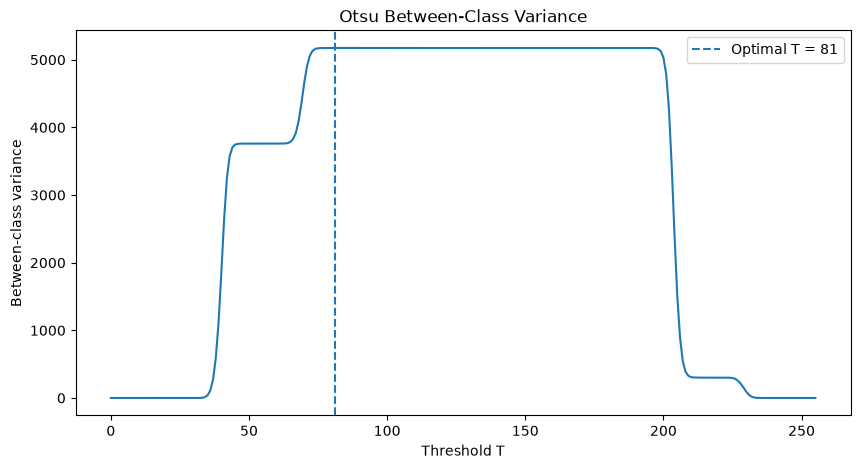

In [344]:
# Plot between-class variance for every possible threshold

plt.figure(figsize=(10, 5))
plt.plot(np.arange(256), sigma_B)
plt.axvline(T_otsu, linestyle="--",
            label=f"Optimal T = {T_otsu}")

plt.xlabel("Threshold T")
plt.ylabel("Between-class variance")
plt.title("Otsu Between-Class Variance")
plt.legend()
plt.show()


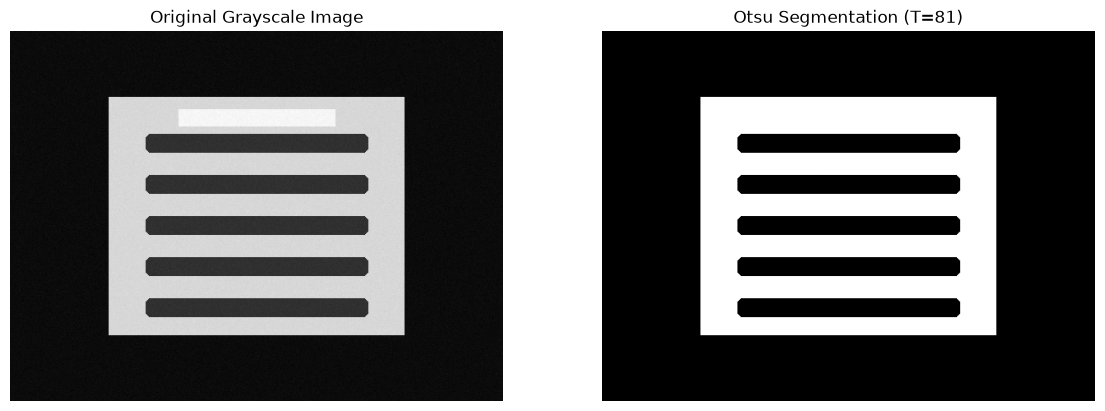

In [345]:


otsu_binary = (otsu_img > T_otsu).astype(np.uint8) * 255

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].imshow(otsu_img, cmap="gray")
ax[0].set_title("Original Grayscale Image")

ax[1].imshow(otsu_binary, cmap="gray")
ax[1].set_title(f"Otsu Segmentation (T={T_otsu})")

for a in ax:
    a.axis("off")

plt.show()


### Q4 Discussion

Otsu's method works well when the histogram is approximately bi-modal because the two classes can be separated by a threshold that produces a large between-class variance.

For a **unimodal histogram**, there may not be a meaningful valley separating foreground and background. Otsu can still return a numerical threshold, but that threshold may not produce useful segmentation.

With **significant illumination variations**, pixels belonging to the same physical object can have substantially different intensities at different locations. A single global threshold may therefore fail. In such cases, adaptive/local thresholding or illumination correction can be more appropriate.